<a href="https://colab.research.google.com/github/harmony-lebovic/image-classifier/blob/main/image_classifier_problem_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import skimage

## Load Data

In [6]:
# If running on colab you can download the data using gdown. Uncomment the below code.
import gdown

!gdown 1JTvMkEaR3AxqAagYzfLebnS_RavA7agR #x_train_img.npz
!gdown 1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1 #x_test_img.npz
!gdown 1tED7-ZgWT0ONtohOD1BCCrlTvXfQM6L0 #x_train.csv
!gdown 1k36wEmeaks1pg2Q5t3aW3e24uxDaUll8 #x_test.csv
!gdown 1J2fEdFSfZnTJ9YwxNnB8qDEOrIOkqbkg #y_train.csv

Downloading...
From (original): https://drive.google.com/uc?id=1JTvMkEaR3AxqAagYzfLebnS_RavA7agR
From (redirected): https://drive.google.com/uc?id=1JTvMkEaR3AxqAagYzfLebnS_RavA7agR&confirm=t&uuid=c3708eb9-2545-4602-a04a-3aa8ba5e5460
To: /content/x_train_img.npz
100% 177M/177M [00:00<00:00, 269MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1
From (redirected): https://drive.google.com/uc?id=1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1&confirm=t&uuid=bd733812-2c0c-4faa-9cda-6e6a6d5e3ca3
To: /content/x_test_img.npz
100% 49.0M/49.0M [00:00<00:00, 212MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tED7-ZgWT0ONtohOD1BCCrlTvXfQM6L0
To: /content/x_train.csv
100% 160k/160k [00:00<00:00, 96.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1k36wEmeaks1pg2Q5t3aW3e24uxDaUll8
To: /content/x_test.csv
100% 40.2k/40.2k [00:00<00:00, 62.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1J2fEdFSfZnTJ9YwxNnB8qDEOrIOkqbkg
To: /content

In [7]:

dev_img_file = "x_train_img.npz"
test_img_file = "x_test_img.npz"

train_metadata_file = "x_train.csv"
test_metadata_file = "x_test.csv"

y_train = "y_train.csv"  # previously "y_file"

In [8]:
X_dev = pd.read_csv(train_metadata_file)
y_dev = pd.read_csv(y_train)

def load_dev_data(train_metadata_file, y_train):
    X_dev = pd.read_csv(train_metadata_file)
    print(f"X_dev loaded from {train_metadata_file}. Shape: {X_dev.shape}. \n")

    y_dev = pd.read_csv(y_train)
    print(f"y_dev loaded from {y_train}. Shape: {y_dev.shape}. \n")

    return X_dev, y_dev

In [9]:
X_test = pd.read_csv(test_metadata_file)

def load_test_data(test_metadata_file):
    X_test = pd.read_csv(test_metadata_file)
    print(f"X_test loaded from {test_metadata_file}. Shape: {X_test.shape}. \n")
    return X_test

In [10]:
# Function and code to load images
def load_img_data(file_path):
    with np.load(file_path) as data:
        img = data['images']
        ids = data['image_ids']
    print(f"Successfully loaded {img.shape[0]} images.")
    return img, ids

dev_imgs, dev_img_ids = load_img_data(dev_img_file)
test_imgs, test_img_ids = load_img_data(test_img_file)
print(dev_img_ids.shape, dev_imgs.shape)
print(test_img_ids.shape, test_imgs.shape)

# Make sure the IDs match and are in the same order
assert np.all(dev_img_ids == X_dev['img_id']), "Image IDs in train metadata and image data do not match"
assert np.all(test_img_ids == X_test['img_id']), "Images IDs in test metadata and image data do not match"

Successfully loaded 1178 images.
Successfully loaded 296 images.
(1178,) (1178, 256, 256, 3)
(296,) (296, 256, 256, 3)


<Axes: xlabel='count', ylabel='fine_label'>

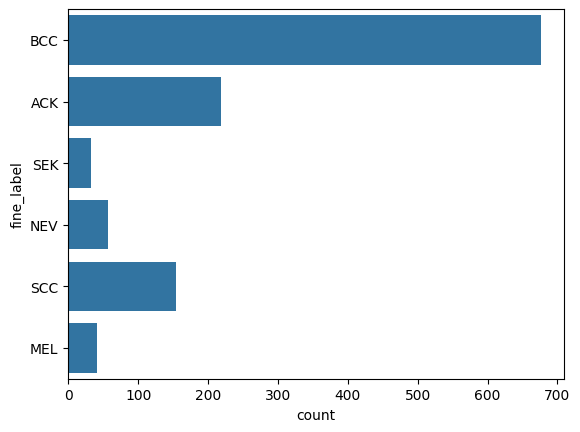

In [11]:
# Plot the class balance
sns.countplot(y_dev["fine_label"])

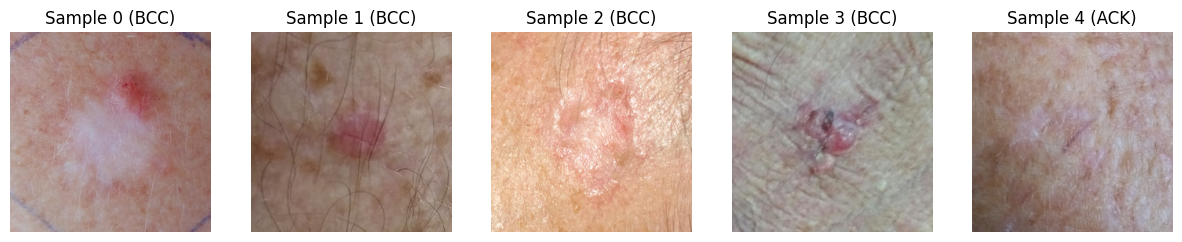

In [12]:
# Show the first 5 images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

k = 0 # optional offset
for i in range(k, 5 + k):
    axes[i-k].imshow(dev_imgs[i])
    axes[i-k].axis('off')
    axes[i-k].set_title(f"Sample {i} ({y_dev.iloc[i]["fine_label"]})")

plt.show()

## Encode Categorical Features

We'll convert all categorical features to one-hot encodings, and all binary features to 1/0.
We can auto-detect the binary features by looking for "True" and "False" (after manually looking through the data to confirm that's how these features are encoded.)

There also is a column labeled "gender". In publicly available datasets it can be especially tricky to figure out what a gender or sex column actually represents. Sometimes it's a patient's legal sex from government records, sometimes it's their biological sex from medical records, sometimes it's the clinician's assumption of the patient's gender, and sometimes it's the patient's self identified gender. The authors of this dataset provide a pdf of [the translated data collection instrument](https://pmc.ncbi.nlm.nih.gov/articles/instance/7479321/bin/mmc2.pdf) where we can see that gender is listed under "Questions About the Patient" and are phrased as questions the clinician would ask the patient directly. Therefore, in this case the gender column most likely represents patient self-identified gender.

In [13]:
# These are the 3 columns in X that have categorical data.
# Everything else is binary or numeric.
categorical_cols = ['background_father', 'background_mother', 'region']

# Get all obvious true/false cols that aren't already true/false
for col in X_dev.select_dtypes(include=['object']):
    if X_dev[col].dropna().astype(str).str.contains('True|False').any():
        print(f"Automatically converting {col} to binary...")
        unmapped = X_dev[~X_dev[col].isin(['True','False'])][col].unique()
        print("The following values are being mapped to NaN in this column: ", unmapped)
        X_dev[col] = X_dev[col].map({'True': 1, 'False': 0, True: 1, False: 0})

X_dev['gender'] = X_dev['gender'].map({'MALE': 0, 'FEMALE': 1})

# Handle the categorical data
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_feats = encoder.fit_transform(X_dev[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_feats,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_dev.index
)

# Drop original text columns and join the new numeric ones
X_dev = X_dev.drop(columns=categorical_cols).join(encoded_df)


Automatically converting itch to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting grew to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting hurt to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting changed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting bleed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting elevation to binary...
The following values are being mapped to NaN in this column:  ['UNK']


In [14]:
# REPEAT FOR TEST DATA
# These are the 3 columns in X that have categorical data.
# Everything else is binary or numeric.
categorical_cols = ['background_father', 'background_mother', 'region']

# Get all obvious true/false cols that aren't already true/false
for col in X_test.select_dtypes(include=['object']):
    if X_test[col].dropna().astype(str).str.contains('True|False').any():
        print(f"Automatically converting {col} to binary...")
        unmapped = X_test[~X_test[col].isin(['True','False'])][col].unique()
        print("The following values are being mapped to NaN in this column: ", unmapped)
        X_test[col] = X_test[col].map({'True': 1, 'False': 0, True: 1, False: 0})

X_test['gender'] = X_test['gender'].map({'MALE': 0, 'FEMALE': 1})

# Handle the categorical data
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_feats = encoder.fit_transform(X_test[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_feats,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

# Drop original text columns and join the new numeric ones
X_test = X_test.drop(columns=categorical_cols).join(encoded_df)

Automatically converting itch to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting grew to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting hurt to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting changed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting bleed to binary...
The following values are being mapped to NaN in this column:  ['UNK']


### Make age groups feature

In [15]:
# Development set
dev_age_groups = pd.cut(
    X_dev['age'],
    bins=[0, 30, 60, 100],
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)']
)

In [16]:
# Test set
test_age_groups = pd.cut(
    X_test['age'],
    bins=[0, 30, 60, 100],
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)']
)

### View class balance by age group

95.2% of seniors (658 observations) are positive.
92.2% of adults (426 observations) are positive.
20.0% of young people (5 observations) are positive.
92.4% of total observations (1089 observations) are positive.


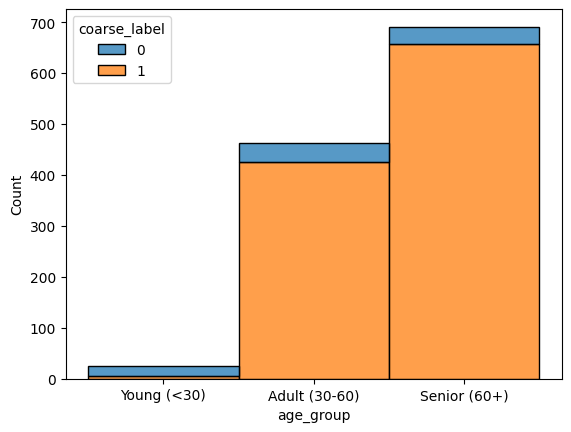

In [17]:
# Create age group column in y_dev
# Don't run this one if doing training because it messses it up

# Deduplicate copy of X_dev
X_dev_deduplicated = X_dev.drop_duplicates(subset='patient_id', inplace=False)
age_lookup = X_dev_deduplicated.set_index('patient_id')['age']

# Map age from X_dev onto y_dev via patient_id
y_dev['age'] = y_dev['patient_id'].map(age_lookup)

# Bin into age groups
y_dev['age_group'] = pd.cut(
    y_dev['age'],
    bins=[0, 30, 60, float('inf')],
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)'],
    right=False
)

# Plot data
sns.histplot(data=y_dev, x="age_group", hue="coarse_label", multiple="stack")

# Print out balance in each age group
seniors_tot = len(y_dev[(y_dev['age_group'] == 'Senior (60+)')])
seniors_pos = len(y_dev[(y_dev['age_group'] == 'Senior (60+)') & (y_dev['coarse_label'] == 1)])
print(f'{round(100 * seniors_pos / seniors_tot, 1)}% of seniors ({seniors_pos} observations) are positive.')

adult_tot = len(y_dev[(y_dev['age_group'] == 'Adult (30-60)')])
adult_pos = len(y_dev[(y_dev['age_group'] == 'Adult (30-60)') & (y_dev['coarse_label'] == 1)])
print(f'{round(100 * adult_pos / adult_tot, 1)}% of adults ({adult_pos} observations) are positive.')

young_tot = len(y_dev[(y_dev['age_group'] == 'Young (<30)')])
young_pos = len(y_dev[(y_dev['age_group'] == 'Young (<30)') & (y_dev['coarse_label'] == 1)])
print(f'{round(100 * young_pos / young_tot, 1)}% of young people ({young_pos} observations) are positive.')

tot_pos = len(y_dev[(y_dev['coarse_label'] == 1)])
print(f'{round(100 * tot_pos / len(X_dev), 1)}% of total observations ({tot_pos} observations) are positive.')

# Remove column after displaying plot
y_dev.drop(columns=['age_group'], inplace=True)

## Handle missing data

In [18]:
# First we'll calculate how much missing data there is
X_dev.isna().sum()

,0
patient_id,0
img_id,0
smoke,0
drink,0
age,0
pesticide,0
gender,0
skin_cancer_history,0
cancer_history,0
has_piped_water,0


In [19]:
# Impute missing data using KNNImputer
from sklearn.impute import KNNImputer
X_dev = X_dev.fillna(0)
X_dev

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,region_EAR,region_FACE,region_FOOT,region_FOREARM,region_HAND,region_LIP,region_NECK,region_NOSE,region_SCALP,region_THIGH
0,PAT_620,PAT_620_001,False,False,55,False,1,True,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,PAT_388,PAT_388_002,False,True,79,False,0,True,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,PAT_518,PAT_518_003,False,True,52,False,1,False,True,True,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,PAT_635,PAT_635_004,False,False,74,True,1,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PAT_447,PAT_447_005,False,True,58,True,1,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1173,PAT_409,PAT_409_1470,True,False,66,False,0,True,False,True,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1174,PAT_640,PAT_640_1471,False,False,41,True,0,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1175,PAT_539,PAT_539_1472,False,False,43,True,1,True,True,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1176,PAT_620,PAT_620_1473,False,False,55,False,1,True,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# Test set
X_test = X_test.fillna(0)
X_test

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,region_EAR,region_FACE,region_FOOT,region_FOREARM,region_HAND,region_LIP,region_NECK,region_NOSE,region_SCALP,region_THIGH
0,PAT_667,PAT_667_275,False,False,71,False,0,True,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,PAT_736,PAT_736_156,False,False,51,True,0,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,PAT_628,PAT_628_085,True,False,58,True,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,PAT_461,PAT_461_083,False,False,80,False,0,False,True,True,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PAT_059,PAT_059_262,False,False,38,False,0,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,PAT_307,PAT_307_189,False,False,75,False,1,True,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
292,PAT_321,PAT_321_072,False,False,71,False,1,False,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
293,PAT_152,PAT_152_107,False,False,67,True,0,False,True,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
294,PAT_526,PAT_526_271,False,False,62,True,1,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Your Code

You might want to revisit the above preprocessing steps for your Problem 2 model. You also might want to put some of the above code into functions to make it easier to apply to different datasets.

### TO DO

In [21]:
# TO DO
# BOTH

# PROBLEM 1
# Rerun without added features to get problem 1 baseline
# Figure 1 with hyperparameters (n_estimators, max_depth)

# PROBLEM 2
# Isolate lesions with pretrained model?
# SHAPley plots for RF
# Resubmit to Gradescope with ideal hyperparameters and reflect on performance for writeup (Problem 1D)
# Interpolate missing values (scipy)

# DONE
# Impute using KNN for missing data
# Augment training dataset for seniors
# CNN on skin lesion
# Route test data to model based on age range
# Make pipeline
# Handle duplicate patient IDs with stratified split
# Turn Booleans into numbers
# Check for duplicates of patient ID
# Do balanced class weight
# Fix symmetry measure
# Add intensity measure
# Turn grids into distributions
# Ask about overfitting for n_estimators
# Implement GroupKFold within pipeline to call groups
# Substitute stdev of each color channel for mean intensity
# Figure out if MinMaxScaler is working correctly on numeric_cols
# Normalize features


In [22]:
# Import libraries
import cv2
import sklearn.ensemble
import sklearn.model_selection
import sklearn.metrics
import math
from pathlib import Path
import os
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

In [23]:
# Activate GPU
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [24]:
# Set random seed for replicability
SEED = 101

## Turn Booleans into numbers

In [25]:
# Development set (from Jeffrey Li's code on Piazza)
bool_cols = X_dev.select_dtypes(include=['bool']).columns
X_dev[bool_cols] = X_dev[bool_cols].astype(int)

# Test set
bool_cols = X_test.select_dtypes(include=['bool']).columns
X_test[bool_cols] = X_test[bool_cols].astype(int)

## Generate numeric features from images

In [26]:
# Symmetry measure
def measure_symmetry(image):
  # Flip image vertically and calculate symmetry
  vert_flip = cv2.flip(image, 0)
  vert_symm = skimage.metrics.structural_similarity(image, vert_flip, channel_axis=2)

  # Flip image horizontally
  horiz_flip = cv2.flip(image, 1)
  horiz_symm = skimage.metrics.structural_similarity(image, horiz_flip, channel_axis=2)

  # Calculate average symmetry
  symmetry = (vert_symm + horiz_symm)/2

  return symmetry

In [27]:
# Intensity stdev measure
def measure_intensity(image):
  stdev_blue, stdev_green, stdev_red = np.std(image, axis=(0,1))

  return stdev_blue, stdev_green, stdev_red

In [28]:
# Parse image ID
def get_img_id(row):
  return int(row['img_id'].split('_')[2])

In [29]:
# Map image ids to indices (got help from Copilot for this)
train_id_to_index = {img_id: int(i) for i, img_id in enumerate(dev_img_ids)}
test_id_to_index = {img_id: int(i) for i, img_id in enumerate(test_img_ids)}

In [30]:
# Add column for symmetry measure
X_dev['symmetry'] = X_dev['img_id'].apply(
    lambda img_id: measure_symmetry(dev_imgs[train_id_to_index[img_id]])
)

X_test['symmetry'] = X_test['img_id'].apply(
    lambda img_id: measure_symmetry(test_imgs[test_id_to_index[img_id]])
)


In [31]:
# Add columns for intensity stdev measures by color channel (got help from Claude for zip syntax)
X_dev['intensity_blue'], X_dev['intensity_green'], X_dev['intensity_red'] = zip(*X_dev['img_id'].apply(
    lambda img_id: measure_intensity(dev_imgs[train_id_to_index[img_id]])
))

X_test['intensity_blue'], X_test['intensity_green'], X_test['intensity_red'] = zip(*X_test['img_id'].apply(
    lambda img_id: measure_intensity(test_imgs[test_id_to_index[img_id]])
))

In [32]:
# Check columns are correct
X_dev.head()

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,region_HAND,region_LIP,region_NECK,region_NOSE,region_SCALP,region_THIGH,symmetry,intensity_blue,intensity_green,intensity_red
0,PAT_620,PAT_620_001,0,0,55,0,1,1,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.547578,13.827750,21.668840,25.263227
1,PAT_388,PAT_388_002,0,1,79,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.511662,14.268699,18.281030,18.465258
2,PAT_518,PAT_518_003,0,1,52,0,1,0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.227869,12.082949,18.590016,22.089448
3,PAT_635,PAT_635_004,0,0,74,1,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.385149,11.291585,16.961407,14.955407
4,PAT_447,PAT_447_005,0,1,58,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.422363,22.398916,25.774490,31.113438


## Ensure features match between development and test sets

In [33]:
# Add zero columns to ensure 100% feature overlap between train and test sets
# Test set
X_test['background_father_AUSTRIA'] = 0
X_test['background_father_CZECH'] = 0
X_test['background_father_ISRAEL'] = 0
X_test['background_father_SPAIN'] = 0
X_test['background_mother_NORWAY'] = 0

# Development set
X_dev['background_mother_FRANCE'] = 0

# Match order of test set columns to development set
X_test = X_test[X_dev.columns]

## Augment images

### Convert to grayscale

In [34]:
dev_imgs_gray = np.empty((1178, 1, 256, 256))

# Convert images to grayscale
for i, img in enumerate(dev_imgs):
  dev_imgs_gray[i] = cv2.cvtColor(dev_imgs[i], cv2.COLOR_BGR2GRAY)
  dev_imgs_gray[i][np.newaxis, :]

In [35]:
test_imgs_gray = np.empty((len(test_imgs), 1, 256, 256))

# Convert images to grayscale
for i, img in enumerate(test_imgs):
  test_imgs_gray[i] = cv2.cvtColor(test_imgs[i], cv2.COLOR_BGR2GRAY)
  test_imgs_gray[i][np.newaxis, :]
  # print(f'Image {i} complete.')

### Class balance visualization

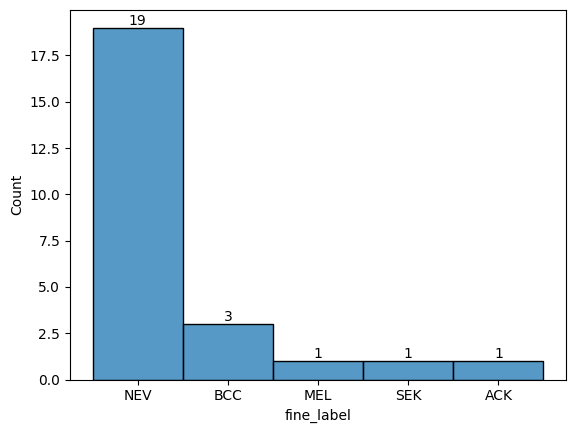

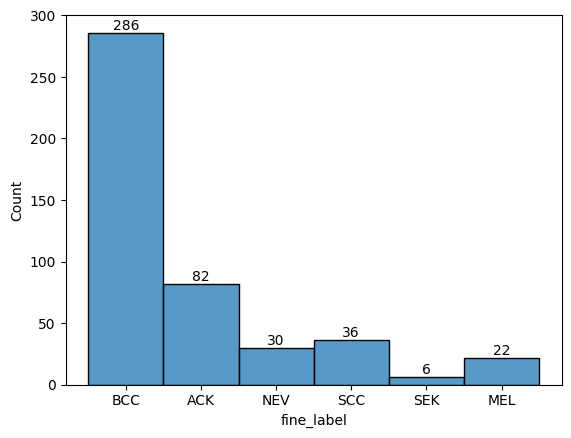

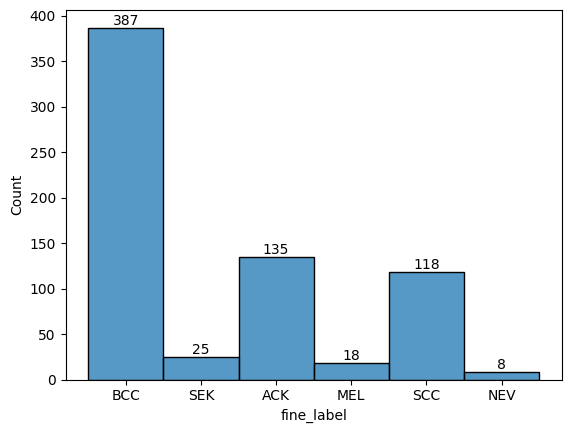

In [36]:
# Deduplicate copy of X_dev
X_dev_deduplicated = X_dev.drop_duplicates(subset='patient_id', inplace=False)
age_lookup = X_dev_deduplicated.set_index('patient_id')['age']

# Map age from X_dev onto y_dev via patient_id
y_dev['age'] = y_dev['patient_id'].map(age_lookup)

# Bin into age groups
y_dev['age_group'] = pd.cut(
    y_dev['age'],
    bins=[0, 30, 60, float('inf')],
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)'],
    right=False
)

# Plot data
#sns.histplot(data=y_dev, x="age_group", hue="fine_label", multiple="stack")

# Plot data
ax = sns.histplot(data=y_dev[y_dev['age_group']=='Young (<30)'], x="fine_label", multiple="stack")

for container in ax.containers:
    ax.bar_label(container)
plt.show()


# Plot data
ax = sns.histplot(data=y_dev[y_dev['age_group']=='Adult (30-60)'], x="fine_label", multiple="stack")

for container in ax.containers:
    ax.bar_label(container)
plt.show()


# Plot data
ax = sns.histplot(data=y_dev[y_dev['age_group']=='Senior (60+)'], x="fine_label", multiple="stack")

for container in ax.containers:
    ax.bar_label(container)
plt.show()

# Remove column after displaying plot
#y_dev.drop(columns=['age_group'], inplace=True)

In [37]:
# cols-1 and rows-1 are the coordinate limits.
img = dev_imgs_gray[0][0,:,:]
img.shape
rows, cols = img.shape

M = cv2.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),90,1)
dst = cv2.warpAffine(img,M,(cols,rows))

In [38]:
# Create pt indexes for SEK, NEV for seniors
senior_benign = y_dev[(y_dev['age_group'] == 'Senior (60+)') & (y_dev['coarse_label'] == 0)]
senior_benign_idx = senior_benign.index.values

imgs = dev_imgs_gray[senior_benign_idx][0, :, :]

### Define augmentation functions

In [39]:
# Define function to rotate images
def rotate_image(img, angle):
  rows, cols = img.shape
  M = cv2.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),90,1)
  rotated_image = cv2.warpAffine(img,M,(cols,rows))
  return rotated_image


# Define function to flip images
def flip_image(img, flip):
  # flip = 0 does vertical flip
  # flip > 0 does horizontal flip
  flipped_image = cv2.flip(img, flip)

  return flipped_image

### Apply augmentations

In [40]:
# Define function to rotate images
def rotate_image(img, angle):
    rows, cols = img.shape
    M = cv2.getRotationMatrix2D(((cols-1)/2.0, (rows-1)/2.0), angle, 1)
    return cv2.warpAffine(img, M, (cols, rows))

# Define function to flip images
def flip_image(img, flip):
    # flip = 0 does vertical flip
    # flip > 0 does horizontal flip
    return cv2.flip(img, flip)

def augment_class(fine_label, angles, flips):
    senior_idx = y_dev[
        (y_dev['age_group'] == 'Senior (60+)') & (y_dev['fine_label'] == fine_label)
    ].index.values

    for orig_idx in senior_idx:
        img_2d = dev_imgs_gray[orig_idx][0, :, :]

        for angle in angles:
            for flip in flips:
                aug = rotate_image(img_2d, angle)
                if flip is not None:
                    aug = flip_image(aug, flip)

                aug_imgs_list.append(aug[np.newaxis])

                for rows_list, df in [(aug_X_rows, X_dev), (aug_y_rows, y_dev)]:
                    row = df.iloc[orig_idx].copy()
                    row['img_id'] = f"{row['img_id']}_rot{angle}_flip{flip}"
                    rows_list.append(row)

aug_imgs_list, aug_X_rows, aug_y_rows = [], [], []

# NEV: 4 angles x 2 flips = 8 transforms
augment_class('NEV', angles=[0, 90, 180, 270], flips=[0, 1])

# MEL: 3 angles x 2 flips = 6 transforms
augment_class('MEL', angles=[0, 90, 180], flips=[0, 1])

# SEK: 3 rotations
augment_class('SEK', angles=[90, 180, 270], flips=[None])

# Concatenate with originals
dev_imgs_aug = np.concatenate([dev_imgs_gray, np.stack(aug_imgs_list)], axis=0)
X_dev_aug = pd.concat([X_dev, pd.DataFrame(aug_X_rows)], ignore_index=True)
y_dev_aug = pd.concat([y_dev, pd.DataFrame(aug_y_rows)], ignore_index=True)

print(f"Original: {len(dev_imgs_gray)} | New: {len(aug_imgs_list)} | Total: {len(dev_imgs_aug)}")

Original: 1178 | New: 247 | Total: 1425


## Handle duplicate patients in train/validation split

In [41]:
# Count total entries in development set
print(f'There are {len(X_dev)} total observations.')

# Count unique patients in development set
print(f'There are {len(pd.unique(X_dev['patient_id']))} unique patients in the dataset.')

There are 1178 total observations.
There are 635 unique patients in the dataset.


In [42]:
# Generate groups patient ids
pat_ids = X_dev['patient_id'].drop_duplicates()
pat_ids['group'] = range(0, len(pat_ids))

x_train_groupings = pd.merge(X_dev, pat_ids, on=['patient_id'], how='left')

# Extract groups
groups = x_train_groupings['patient_id'].values

# Split using GroupShuffleSplit
split = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=SEED)
split.get_n_splits()

# Capture training and validation indices
train_idx, val_idx = next(split.split(X_dev, y_dev, groups))

# Separate training and validation sets
X_train = X_dev.iloc[train_idx]
X_val = X_dev.iloc[val_idx]
y_train = y_dev.iloc[train_idx]
y_val = y_dev.iloc[val_idx]

# Capture groupings in training and validation sets
train_groups = groups[train_idx]
val_groups = groups[val_idx]

# Determine if there are any overlapping groups
shared_groups = list(set(train_groups) & set(val_groups))
print(shared_groups)

[]


### GroupShuffleSplit for images

In [43]:
# REPEAT FOR IMAGES
# Extract groups from augmented tabular data (patient_id carries through augmentation)
groups_aug = X_dev_aug['patient_id'].values

# Split using GroupShuffleSplit
split = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=SEED)

# Capture training and validation indices
train_img_idx_aug, val_img_idx_aug = next(split.split(dev_imgs_aug, y_dev_aug['fine_label'].values, groups_aug))

## Remove patient/image ID information

In [44]:
# Remove patient and image ids from training and validation sets
X_train_clean = X_train.drop(columns=['patient_id', 'img_id'])
X_val_clean = X_val.drop(columns=['patient_id', 'img_id'])
y_train_clean = y_train['coarse_label']
y_val_clean = y_val['coarse_label']

# Remove patient and image ids from test set
X_test_clean = X_test.drop(columns=['patient_id', 'img_id'])

# Remove patient and image ids from development set
X_dev_clean = X_dev.drop(columns=['patient_id', 'img_id'])
y_dev_clean = y_dev['coarse_label']

## Select random forest hyperparameters

In [45]:
# Calculate total possible features
total_features = len(X_dev.columns)

In [46]:
random_forest = RandomForestClassifier(
    n_estimators=1000,
    criterion='entropy',
    max_depth=16,
    max_features=total_features,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=SEED
)

In [47]:
# Set up GroupKFold to prevent overlap during hyperparameter optimization
group_k_fold = sklearn.model_selection.GroupKFold(n_splits=5)

In [48]:
# Generate imputer for missing data
imputer = KNNImputer(n_neighbors=2)

In [49]:
search_hyp = {
    'model__max_features': [int(math.sqrt(total_features)), int(math.log2(total_features)), int(total_features/3)],
    'model__criterion': ['entropy', 'gini', 'log_loss'],
    'model__max_depth': np.linspace(1, 16, 4, dtype=int),
    'model__n_estimators': np.linspace(100, 2000, 50, dtype=int),
    'model__random_state': [SEED],
    'model__class_weight': ['balanced'],
    'impute__n_neighbors': np.linspace(5, 20, 5, dtype=int)
}

In [50]:
# Define pipeline
pipeline = Pipeline([
    ('impute', imputer),
    ('scale', MinMaxScaler(feature_range=(0,1))),
    ('model', random_forest)
])

In [51]:
# Define random searcher with specified options
forest_searcher = sklearn.model_selection.RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=search_hyp,
    n_iter=50,
    scoring='balanced_accuracy',
    refit=False,
    return_train_score=True,
    cv=group_k_fold,
    verbose=3)

In [52]:
# Fit forest searcher on the development set
forest_searcher.fit(X_dev_clean, y_dev_clean, groups=groups)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END impute__n_neighbors=8, model__class_weight=balanced, model__criterion=gini, model__max_depth=16, model__max_features=20, model__n_estimators=1457, model__random_state=101;, score=(train=1.000, test=0.498) total time=   4.2s
[CV 2/5] END impute__n_neighbors=8, model__class_weight=balanced, model__criterion=gini, model__max_depth=16, model__max_features=20, model__n_estimators=1457, model__random_state=101;, score=(train=1.000, test=0.600) total time=   5.0s
[CV 3/5] END impute__n_neighbors=8, model__class_weight=balanced, model__criterion=gini, model__max_depth=16, model__max_features=20, model__n_estimators=1457, model__random_state=101;, score=(train=1.000, test=0.591) total time=   3.9s
[CV 4/5] END impute__n_neighbors=8, model__class_weight=balanced, model__criterion=gini, model__max_depth=16, model__max_features=20, model__n_estimators=1457, model__random_state=101;, score=(train=1.000, test=0.629) total tim

RandomizedSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('impute',
                                              KNNImputer(n_neighbors=2)),
                                             ('scale', MinMaxScaler()),
                                             ('model',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     criterion='entropy',
                                                                     max_depth=16,
                                                                     max_features=62,
                                                                     n_estimators=1000,
                                                                     random_state=101))]),
                   n_iter=50,
                   param_distributions={'impute__n...
                                        'model__n_estimators': array([ 100,  138,  177,  216,  255,  293,  332,  371,  410,  448,  487,
        526,  565,  604,  642,  681,  720,  759,  797,  836,  875,  914,
        953,  991, 1030, 1069, 1108, 1146, 1185, 1224, 1263, 1302, 1340,
       1379, 1418, 1457, 1495, 1534, 1573, 1612, 1651, 1689, 1728, 1767,
       1806, 1844, 1883, 1922, 1961, 2000]),
                                        'model__random_state': [101]},
                   refit=False, return_train_score=True,
                   scoring='balanced_accuracy', verbose=3)

In [53]:
best_params = forest_searcher.best_params_
best_params

{'model__random_state': 101,
 'model__n_estimators': np.int64(177),
 'model__max_features': 7,
 'model__max_depth': np.int64(1),
 'model__criterion': 'gini',
 'model__class_weight': 'balanced',
 'impute__n_neighbors': np.int64(5)}

In [54]:
# Refit best model on development set
random_forest = sklearn.ensemble.RandomForestClassifier(
    n_estimators=forest_searcher.best_params_['model__n_estimators'],
    criterion=forest_searcher.best_params_['model__criterion'],
    max_depth=forest_searcher.best_params_['model__max_depth'],
    max_features=forest_searcher.best_params_['model__max_features'],
    class_weight='balanced',
    random_state=forest_searcher.best_params_['model__random_state']
)

imputer = KNNImputer(n_neighbors=forest_searcher.best_params_['impute__n_neighbors'])

# Reset model in pipeline
pipeline = Pipeline([
    ('imputer', imputer),
    ('scale', MinMaxScaler(feature_range=(0,1))),
    ('model', random_forest),
])
pipeline.set_output(transform='pandas')

# Fit pipeline on training data only
pipeline.fit(X_train_clean, y_train_clean)

Pipeline(steps=[('imputer', KNNImputer(n_neighbors=np.int64(5))),
                ('scale', MinMaxScaler()),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        max_depth=np.int64(1), max_features=7,
                                        n_estimators=np.int64(177),
                                        random_state=101))])

### Calculate performance on train and validation sets

In [55]:
# Predict classes
yhat_train = pipeline.predict_proba(X_train_clean)[:,1]
yhat_val = pipeline.predict_proba(X_val_clean)[:,1]

# Calculate AUCROC
train_AUCROC = sklearn.metrics.roc_auc_score(y_train_clean, yhat_train)
val_AUCROC = sklearn.metrics.roc_auc_score(y_val_clean, yhat_val)

# Print scores
print(f'Training AUCROC: {round(train_AUCROC, 3)}')
print(f'Validation AUCROC: {round(val_AUCROC, 3)}')

Training AUCROC: 0.935
Validation AUCROC: 0.901


In [56]:
# Pull out indices of different age groups
train_age_groups = dev_age_groups[train_idx]
val_age_groups = dev_age_groups[val_idx]

seniors_train = train_age_groups.index[train_age_groups == 'Senior (60+)']
adults_train = train_age_groups.index[train_age_groups == 'Adult (30-60)']
young_train = train_age_groups.index[train_age_groups == 'Young (<30)']

seniors_val = val_age_groups.index[val_age_groups == 'Senior (60+)']
adults_val = val_age_groups.index[val_age_groups == 'Adult (30-60)']
young_val = val_age_groups.index[val_age_groups == 'Young (<30)']

In [57]:
# Predict on each group separately
yhat_train_young = pipeline.predict_proba(X_train_clean[X_train_clean.index.isin(young_train)])[:,1]
yhat_val_young = pipeline.predict_proba(X_val_clean[X_val_clean.index.isin(young_val)])[:,1]
yhat_train_adult = pipeline.predict_proba(X_train_clean[X_train_clean.index.isin(adults_train)])[:,1]
yhat_val_adult = pipeline.predict_proba(X_val_clean[X_val_clean.index.isin(adults_val)])[:,1]
yhat_train_senior = pipeline.predict_proba(X_train_clean[X_train_clean.index.isin(seniors_train)])[:,1]
yhat_val_senior = pipeline.predict_proba(X_val_clean[X_val_clean.index.isin(seniors_val)])[:,1]

# Performance on young group
train_AUCROC_young = sklearn.metrics.roc_auc_score(y_train_clean[y_train_clean.index.isin(young_train)], yhat_train_young)
val_AUCROC_young = sklearn.metrics.roc_auc_score(y_val_clean[y_val_clean.index.isin(young_val)], yhat_val_young)
print(f'Training AUCROC on young observations: {round(train_AUCROC_young, 3)}')
print(f'Validation AUCROC on young observations: {round(val_AUCROC_young, 3)}')
print('Confusion matrix for young validation data:')
yhat_val_young_int = (yhat_val_young + 0.5).astype(int)
print(sklearn.metrics.confusion_matrix(y_val_clean[y_val_clean.index.isin(young_val)], yhat_val_young_int))

# Performance on adult group
train_AUCROC_adult = sklearn.metrics.roc_auc_score(y_train_clean[y_train_clean.index.isin(adults_train)], yhat_train_adult)
val_AUCROC_adult = sklearn.metrics.roc_auc_score(y_val_clean[y_val_clean.index.isin(adults_val)], yhat_val_adult)
print(f'\nTraining AUCROC on adult observations: {round(train_AUCROC_adult, 3)}')
print(f'Validation AUCROC on adult observations: {round(val_AUCROC_adult, 3)}')
yhat_val_adult_int = (yhat_val_adult + 0.5).astype(int)
print(sklearn.metrics.confusion_matrix(y_val_clean[y_val_clean.index.isin(adults_val)], yhat_val_adult_int))

# Performance on seniors group
train_AUCROC_senior = sklearn.metrics.roc_auc_score(y_train_clean[y_train_clean.index.isin(seniors_train)], yhat_train_senior)
val_AUCROC_senior = sklearn.metrics.roc_auc_score(y_val_clean[y_val_clean.index.isin(seniors_val)], yhat_val_senior)
print(f'\nTraining AUCROC on senior observations: {round(train_AUCROC_senior, 3)}')
print(f'Validation AUCROC on senior observations: {round(val_AUCROC_senior, 3)}')
yhat_val_senior_int = (yhat_val_senior + 0.5).astype(int)
print(sklearn.metrics.confusion_matrix(y_val_clean[y_val_clean.index.isin(seniors_val)], yhat_val_senior_int))

Training AUCROC on young observations: 1.0
Validation AUCROC on young observations: 0.133
Confusion matrix for young validation data:
[[5 0]
 [3 0]]

Training AUCROC on adult observations: 0.918
Validation AUCROC on adult observations: 0.968
[[ 7  0]
 [12 92]]

Training AUCROC on senior observations: 0.911
Validation AUCROC on senior observations: 0.774
[[ 3  2]
 [21 88]]


### Produce feature importance plot to understand RF
https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.htmldecision making

Text(0.5, 0, 'Mean impurity decrease')

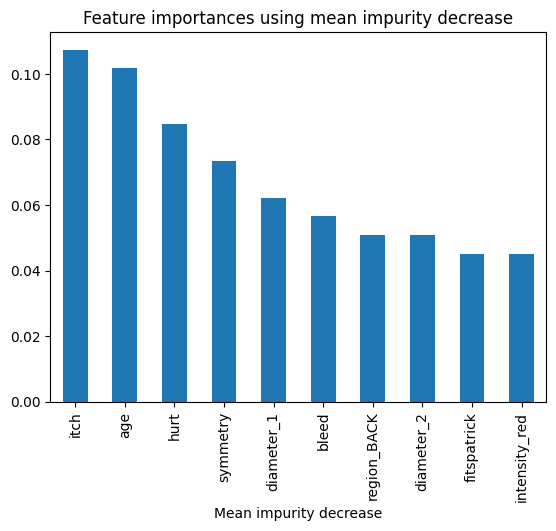

In [58]:
import matplotlib.pyplot as plt
importances = random_forest.feature_importances_
feature_names = X_train_clean.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
forest_importances.nlargest(10).plot(kind='bar')
plt.title('Feature importances using mean impurity decrease')
plt.xlabel('Mean impurity decrease')


## Try out EfficientNet pretrained model

In [52]:
import keras
from keras.applications.efficientnet import EfficientNetB2
from transformers import EfficientNetImageProcessor
import cv2
import tensorflow as tf
from keras.callbacks import EarlyStopping
from sklearn.utils import class_weight

In [53]:
# Establish early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [54]:
# Split development images into train and validation
train_imgs = dev_imgs[train_idx]
val_imgs = dev_imgs[val_idx]

# Resize images to be (260 x 260 x 3) which is required for input to EfficientNet
processed_train_imgs = tf.image.resize(train_imgs, [260, 260]).numpy()
processed_val_imgs = tf.image.resize(val_imgs, [260, 260]).numpy()
processed_test_imgs = tf.image.resize(test_imgs, [260, 260]).numpy()
processed_dev_imgs = tf.image.resize(dev_imgs, [260, 260]).numpy()

In [65]:
# REPEAT FOR AUGMENTED IMAGES
# Split development images into train and validation
train_imgs = dev_imgs_aug[train_idx_aug]
val_imgs = dev_imgs_aug[val_idx_aug]

# Resize images to be (260 x 260 x 3) which is required for input to EfficientNet
processed_train_imgs_aug = tf.image.resize(train_imgs_aug, [260, 260]).numpy()
processed_val_imgs_aug = tf.image.resize(val_imgs_aug, [260, 260]).numpy()
processed_test_imgs = tf.image.resize(test_imgs, [260, 260]).numpy()
processed_dev_imgs_aug = tf.image.resize(dev_imgs_aug, [260, 260]).numpy()

NameError: name 'train_idx_aug' is not defined

In [62]:
# Initialize EfficientNetModel with no top layer (we will add a classification layer with 2 classes)
base_model = EfficientNetB2(
    weights='IMAGENET1K_V1',
    input_shape=(260,260,3),
    include_top=False)

# Don't retrain base model
base_model.trainable = False

In [63]:
# Create new layer to perform binary classification
inputs = keras.Input(shape=(260,260,3))
x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

In [64]:
# Compile model and set up parameters
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=[keras.metrics.BinaryAccuracy()])

In [65]:
# Determine class weighting
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_clean),
    y=y_train_clean
)

class_weights = dict(zip(np.unique(y_train_clean), weights))

In [66]:
# Train model (stop early)
hist = model.fit(processed_train_imgs,
                 y_train_clean, epochs=15,
                 validation_data=(processed_val_imgs, y_val_clean),
                 class_weight=class_weights,
                 callbacks=[early_stop])

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - binary_accuracy: 0.2936 - loss: 0.6715  

KeyboardInterrupt: 

In [ ]:
# Plot accuracy across epochs
def plot_hist(hist):
  plt.plot(hist.history['binary_accuracy'])
  plt.plot(hist.history['val_binary_accuracy'])
  plt.title('model accuracy')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.legend(['train', 'validation'], loc='upper left')
  plt.show()

plot_hist(hist)

In [ ]:
# Make predictions on train and validation sets
yhat_train = tf.nn.sigmoid(model.predict(processed_train_imgs)).numpy()
yhat_val = tf.nn.sigmoid(model.predict(processed_val_imgs)).numpy()
yhat_dev = tf.nn.sigmoid(model.predict(processed_dev_imgs)).numpy()

# Integer predictions
yhat_train_pred = (yhat_train + 0.5).astype(int)
yhat_val_pred = (yhat_val + 0.5).astype(int)
yhat_dev_pred = (yhat_dev + 0.5).astype(int)

In [ ]:
# Calculate AUCROC
train_AUCROC = sklearn.metrics.roc_auc_score(y_train_clean, yhat_train)
val_AUCROC = sklearn.metrics.roc_auc_score(y_val_clean, yhat_val)

# Print scores
print(f'Training AUCROC: {round(train_AUCROC, 3)}')
print(f'Validation AUCROC: {round(val_AUCROC, 3)}')

In [ ]:
# Look at confusion matrix (old)
print(sklearn.metrics.confusion_matrix(y_val_clean[y_val_clean.index.isin(seniors_val)], yhat_val_pred[seniors_val]))

## Try training our own CNN

In [3]:
# Import required libraries
import cv2
import torch           # Main PyTorch library - provides tensors (like numpy arrays but GPU-compatible)
import torch.nn as nn  # Neural network building blocks: layers (Linear, Conv2d), loss functions (CrossEntropyLoss)
import torch.optim as optim  # Optimization algorithms that update model weights during training like SGD, Adam
import torch.nn.functional as F  # Stateless functions (no learnable parameters) like activation functions (relu, sigmoid), loss functions, pooling
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset, DataLoader, random_split  # DataLoader used since PyTorch datasets are often too big for memory
import torchvision.datasets as datasets  # Built-in benchmark datasets ready to download and use like MNIST, CIFAR-10
import torchvision.transforms as transforms # Image preprocessing and augmentation pipelines such as ToTensor()

In [45]:
train_imgs_aug = dev_imgs_aug[train_img_idx_aug]
val_imgs_aug = dev_imgs_aug[val_img_idx_aug]

In [46]:
print(train_imgs_aug.shape)
print(val_imgs_aug.shape)

(1159, 1, 256, 256)
(266, 1, 256, 256)


In [47]:
# ── DATASET SIZE ─────────────────────────────────────────────────────────────
print(f"Training samples:   {len(train_imgs_aug)}")
print(f"Validation samples: {len(val_imgs_aug)}")
print(f"Test samples:       {len(test_imgs)}")

# ── IMAGE SIZE ───────────────────────────────────────────────────────────────
# Grab a single image and label from the dataset
sample_image = dev_imgs_aug[0]

print(f"\nRaw tensor shape: {sample_image.shape}")   # (C, H, W)
print(f"  Channels: {sample_image.shape[0]}  ← grayscale=1, RGB=3")
print(f"  Height:   {sample_image.shape[1]}  ← pixels")
print(f"  Width:    {sample_image.shape[2]}  ← pixels")
print(f"  Label:    UNK")

# ── HOW THIS MAPS TO THE CNN ──────────────────────────────────────────────────
print(f"\nCNN input settings:")
print(f"  in_channels = {sample_image.shape[0]}  ← matches number of image channels")
print(f"  in_features = {sample_image.shape[0]} × {sample_image.shape[1]} × {sample_image.shape[2]} = {sample_image.shape[0] * sample_image.shape[1] * sample_image.shape[2]}")

Training samples:   1159
Validation samples: 266
Test samples:       296

Raw tensor shape: (1, 256, 256)
  Channels: 1  ← grayscale=1, RGB=3
  Height:   256  ← pixels
  Width:    256  ← pixels
  Label:    UNK

CNN input settings:
  in_channels = 1  ← matches number of image channels
  in_features = 1 × 256 × 256 = 65536


In [48]:
## CNN architecture
class CNN(nn.Module):
  def __init__(self, in_channels=1, num_class=2):
    super(CNN, self).__init__()

    # Subtask 1: 2D Convolution layer
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))

    # Subtask 2: Add a ReLU activation
    self.relu1 = nn.ReLU()

    # Subtask 3: Add a MaxPool layer to halve the spatial dimensions
    self.maxpool1 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0,0))

    # Subtask 4: Add a 2D BatchNorm layer
    self.batchnorm1 = nn.BatchNorm2d(8)

    # Subtask 5: Add another 2D Convolution layer
    self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))

    # Subtask 6: Add a ReLU activation
    self.relu2 = nn.ReLU()

    # Subtask 7: Add another 2D Convolution layer
    self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))

    # Subtask 8: Add a ReLU activation
    self.relu3 = nn.ReLU()

    # Subtask 9: Add another MaxPool layer to quarter the spatial dimensions
    self.maxpool2 = nn.MaxPool2d(kernel_size=(4, 4), stride=(4, 4), padding=(0,0))

    # Subtask 10: Add a 2D BatchNorm layer
    self.batchnorm2 = nn.BatchNorm2d(32)

    # Subtask 11: Add another 2D Convolution layer
    self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))

    # Subtask 12: Add a ReLU activation
    self.relu4 = nn.ReLU()

    # Subtask 13: Add another 2D Convolution layer
    self.conv5 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))

    # Subtask 14: Add a ReLU activation
    self.relu5 = nn.ReLU()

    # Subtask 15: Add anotehr MaxPool layer to quarter the spatial dimensions
    self.maxpool3 = nn.MaxPool2d(kernel_size=(4, 4), stride=(4, 4), padding=(0,0))

    # Subtask 16: Flatten data
    self.fc = nn.Linear(128 * 8 * 8, 2)

    # Subtask 17: Sigmoid
    self.softmax = nn.Softmax()

  def forward(self, x):
    """ Defines forward pass """

    # First Convolutional layer -> first MaxPool layer
    x = self.maxpool1(self.relu1(self.conv1(x)))

    # First BatchNorm layer
    x = self.batchnorm1(x)

    # Second Convolutional layer
    x = self.relu2(self.conv2(x))

    # Third Convolutional layer -> second MaxPool layer
    x = self.maxpool2(self.relu3(self.conv3(x)))

    # Second BatchNorm layer
    x = self.batchnorm2(x)

    # Fourth Convolutional layer
    x = self.relu4(self.conv4(x))

    # Fifth Convolutional layer -> third MaxPool layer
    x = self.maxpool3(self.relu5(self.conv5(x)))

    # Flatten data
    x = self.fc(x.reshape(x.shape[0], -1))

    # Return sigmoided results
    # x = self.softmax(x)

    return x


In [49]:
# Training and Validation functions

def train_step(model, data, targets, loss_fn, optimizer):
  """
    Performs one mini-batch update during training:
        1. Forward pass  → compute predictions and loss
        2. Backward pass → compute gradients via backpropagation
        3. Weight update → optimizer adjusts model parameters

    Args:
        model     : The CNN model being trained
        data      : One batch of input images,  shape (batch_size, 1, 28, 28)
        targets   : One batch of true labels,   shape (batch_size,)
        loss_fn   : Loss function e.g. nn.CrossEntropyLoss()
        optimizer : Optimizer e.g. optim.Adam()

    Returns:
        loss.item()  : Scalar loss value for this batch (plain Python float, not a tensor)
        num_correct  : Number of correct predictions in this batch
        num_samples  : Total number of samples in this batch (usually = batch_size)
  """
  model.train() # Set the model to training mode. This enables layers that behave differently during training vs evaluation

  # MOVE DATA TO DEVICE
  # PyTorch requires ALL tensors involved in a computation to be on the SAME device.
  # .to(device) moves the tensor to whichever device was set earlier
  data = data.to(device=device)
  targets = targets.to(device=device)

  # FORWARD PASS
  # Pass the batch of images through the model.
  # Internally calls model.forward(data) and returns raw class scores (logits)
  # Shape: (batch_size, num_classes) e.g. (64, 10) for MNIST
  scores = model(data)

  # Compute how wrong the model's predictions are compared to the true labels.
  # CrossEntropyLoss applies softmax to scores internally, then computes
  # negative log likelihood. Returns a single scalar value averaged over the batch.
  loss = loss_fn(scores, targets.view(-1).long())

  # BACKWARD PASS
  optimizer.zero_grad()  # set all gradients to zero for each batch bc by default, gradients are accumulated in PyTorch
  loss.backward() # backpropagation to compute gradient of the loss with respect to all trainable parameters in the model

  # gradient descent
  optimizer.step() # optimizer updates model parameters using gradients computed during backpropagation

  # Accumulate loss and accuracy
  predictions = torch.argmax(scores, dim=1)
  num_correct = (predictions == targets.view(-1)).sum().item()
  num_samples = len(predictions)

  return loss.item(), num_correct, num_samples


def validation_step(model, data, targets, loss_fn):
  """
    Performs one mini-batch evaluation during validation.
    No gradient computation or weight updates occur here —
    we are only measuring how well the model generalises to unseen data.

    Args:
        model   : The CNN model being evaluated
        data    : One batch of input images,  shape (batch_size, 1, 28, 28)
        targets : One batch of true labels,   shape (batch_size,)
        loss_fn : Loss function e.g. nn.CrossEntropyLoss()

    Returns:
        loss.item()           : Scalar loss value for this batch
        num_correct           : Number of correct predictions in this batch
        num_samples           : Total samples in this batch
  """
  model.eval() # Set the model to evaluation mode

  # Move batch to the same device as the model
  data = data.to(device=device)
  targets = targets.to(device=device)

  # During validation we never call loss.backward(), so gradients are unnecessary.
  with torch.no_grad(): # Disable gradient calculation for validation

    # Forward pass only — no backward pass or weight update
    scores = model(data)
    loss = loss_fn(scores, targets.view(-1).long())

    # Same accuracy calculation as train_step
    predictions = torch.argmax(scores, dim=1)
    num_correct = (predictions == targets.view(-1)).sum().item()
    num_samples = len(predictions)

  return loss.item(), num_correct, num_samples

In [55]:
# DEVICE SETUP
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# HYPERPARAMETERS
in_channel = 1
num_classes = 2 # Binary classification task
learning_rate = 0.0001 # step size used for each iteration
batch_size = 64

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_clean),
    y=y_train_clean
)
weights = torch.tensor(weights, dtype=torch.float32).to(device) # Correct for class imbalance

# INITIALISE NETWORK
model = CNN().to(device)

# LOSS FUNCTION
loss_fn = nn.CrossEntropyLoss(weight=weights)

# OPTIMIZER
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [58]:
# Generate train and validation data loaders
train_imgs_tensor = torch.from_numpy(dev_imgs_aug[train_img_idx_aug].astype(np.float32))
val_imgs_tensor = torch.from_numpy(dev_imgs_aug[val_img_idx_aug].astype(np.float32))

# Align labels with the augmented split indices
y_train_aug = y_dev_aug['coarse_label'].iloc[train_img_idx_aug].reset_index(drop=True)
y_val_aug = y_dev_aug['coarse_label'].iloc[val_img_idx_aug].reset_index(drop=True)

train_class_tensor = torch.from_numpy(y_train_aug.to_numpy().reshape(-1, 1).astype(np.float32))
val_class_tensor = torch.from_numpy(y_val_aug.to_numpy().reshape(-1, 1).astype(np.float32))

train_dataset = TensorDataset(train_imgs_tensor, train_class_tensor)
val_dataset = TensorDataset(val_imgs_tensor, val_class_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

# Test data loader
test_imgs_tensor = torch.from_numpy(test_imgs_gray.astype(np.float32))

In [59]:
# -------- TRACKING METRICS ---------
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

# Early stopping settings
patience = 5
best_val_loss = float('inf')
epochs_without_improvement = 0
best_model_weights = None

EPOCHS = 20

# -------- TRAINING LOOP -----------
for epoch in range(EPOCHS):
  running_loss = 0.0
  num_correct = 0
  num_samples = 0

  val_running_loss = 0.0
  val_num_correct = 0
  val_num_samples = 0

  for batch_idx, (data, targets) in enumerate(train_loader):
    loss, num_corr, num_sam = train_step(model, data, targets, loss_fn, optimizer)
    running_loss += loss
    num_correct += num_corr
    num_samples += num_sam

  for batch_idx, (data, targets) in enumerate(val_loader):
    loss, num_corr, num_sam = validation_step(model, data, targets, loss_fn)
    val_running_loss += loss
    val_num_correct += num_corr
    val_num_samples += num_sam

  epoch_loss = running_loss / len(train_loader)
  epoch_acc  = float(num_correct) / float(num_samples) * 100

  train_losses.append(epoch_loss)
  train_accuracies.append(epoch_acc)

  val_epoch_loss = val_running_loss / len(val_loader)
  val_epoch_acc  = float(val_num_correct) / float(val_num_samples) * 100

  val_losses.append(val_epoch_loss)
  val_accuracies.append(val_epoch_acc)

  print(
      f'Epoch {epoch+1}, '
      f'Loss: {epoch_loss:0.2f}, '
      f'Train Acc: {epoch_acc:0.2f}, '
      f'Val Loss: {val_epoch_loss:0.2f}, '
      f'Val Acc: {val_epoch_acc:0.2f}'
  )

  # Early stopping check
  if val_epoch_loss < best_val_loss:
    best_val_loss = val_epoch_loss
    epochs_without_improvement = 0
    best_model_weights = model.state_dict().copy()
  else:
    epochs_without_improvement += 1
    if epochs_without_improvement >= patience:
      print(f'Early stopping at epoch {epoch+1}')
      break

# Restore best weights
model.load_state_dict(best_model_weights)

Epoch 1, Loss: 0.67, Train Acc: 30.54, Val Loss: 0.65, Val Acc: 21.05
Epoch 2, Loss: 0.61, Train Acc: 32.27, Val Loss: 0.61, Val Acc: 20.30
Epoch 3, Loss: 0.57, Train Acc: 22.69, Val Loss: 0.60, Val Acc: 46.99
Epoch 4, Loss: 0.55, Train Acc: 40.38, Val Loss: 0.60, Val Acc: 25.94
Epoch 5, Loss: 0.53, Train Acc: 36.41, Val Loss: 0.57, Val Acc: 37.22
Epoch 6, Loss: 0.50, Train Acc: 43.31, Val Loss: 0.56, Val Acc: 40.23
Epoch 7, Loss: 0.49, Train Acc: 47.02, Val Loss: 0.56, Val Acc: 41.35
Epoch 8, Loss: 0.46, Train Acc: 52.55, Val Loss: 0.55, Val Acc: 46.62
Epoch 9, Loss: 0.45, Train Acc: 55.05, Val Loss: 0.54, Val Acc: 46.24
Epoch 10, Loss: 0.43, Train Acc: 58.84, Val Loss: 0.52, Val Acc: 53.76
Epoch 11, Loss: 0.45, Train Acc: 63.16, Val Loss: 0.51, Val Acc: 57.89
Epoch 12, Loss: 0.42, Train Acc: 70.58, Val Loss: 0.51, Val Acc: 63.16
Epoch 13, Loss: 0.40, Train Acc: 70.23, Val Loss: 0.52, Val Acc: 70.30
Epoch 14, Loss: 0.37, Train Acc: 65.66, Val Loss: 0.52, Val Acc: 67.29
Epoch 15, Loss:

<All keys matched successfully>

In [60]:
# Evaluate on test data

# Set model to evaluation mode
model.to(device)
model.eval()

# Send test data to device
test_tensor = test_imgs_tensor.to(device)

# Predict classes
with torch.no_grad():
  output = model(test_tensor)

# Get probabilities
output = torch.softmax(output, dim=1)

# Conver to numpy array
output = output.detach().cpu().numpy()[:,1]

In [61]:
# Delete previous file, if exists
if Path('yproba1_test.txt').exists():
  os.remove('yproba1_test.txt')

# Save results to .txt file
file = open('yproba1_test.txt', "x")

with open('yproba1_test.txt', "w") as f:
    f.write('\n'.join(output.astype('str')))

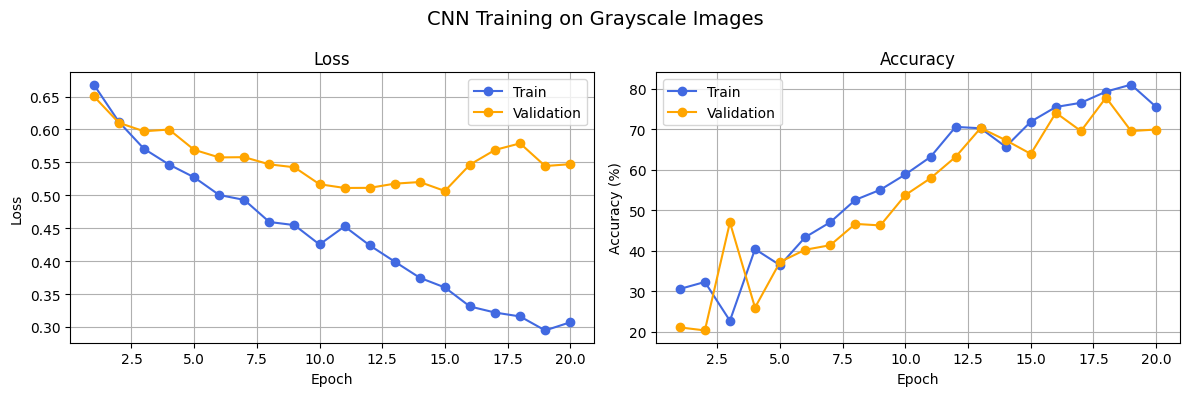

In [62]:
# ---- Plot Training Curves ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CNN Training on Augmented Images', fontsize=14)

ax1.plot(range(1, EPOCHS+1), train_losses, marker='o', color='royalblue', label='Train')
ax1.plot(range(1, EPOCHS+1), val_losses,   marker='o', color='orange', label='Validation')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, EPOCHS+1), train_accuracies, marker='o', color='royalblue', label='Train')
ax2.plot(range(1, EPOCHS+1), val_accuracies,   marker='o', color='orange',    label='Validation')

ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [63]:
# Test the Model
def test_model(loader, model):

    num_correct = 0
    num_samples = 0
    model.eval()

    with torch.no_grad():  # dont compute gradients
        for x, y in loader:
            x = x.to(device=device)
            y = y.to(device=device)

            scores = model(x)
            predictions = (scores >= 0.5).int()

            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

        print(f'Accuracy on testing data: {float(num_correct)/float(num_samples)*100: .2f}')

    model.train()

In [64]:
test_model(val_loader, model)

Accuracy on testing data:  77.82


## Make final predictions on test set

In [ ]:
# Make predictions on test set - random forest
# yhat_test = random_forest.predict_proba(X_test_clean)[:,1]

In [ ]:
# Make predictions on test set - pretrained model
yhat_test = tf.nn.sigmoid(model.predict(processed_test_imgs)).numpy().ravel()

In [ ]:
# Delete previous file, if exists
if Path('yproba1_test.txt').exists():
  os.remove('yproba1_test.txt')

# Save results to .txt file
file = open('yproba1_test.txt', "x")

with open('yproba1_test.txt', "w") as f:
    f.write('\n'.join(yhat_test.astype('str')))

### Loop over values of n_estimators and see resulting performance on training and validation sets

In [ ]:
# Set up range of options
n_estimators_range = np.linspace(100, 2000, 20, dtype=int)

# Set up dictionaries to hold train and validation AUROCs
tr_AUROC = {}
val_AUROC = {}

In [ ]:
# Loop through values of n_estimators and calculate training and validation scores for 5 folds
kf = sklearn.model_selection.KFold(n_splits=5)
kf.get_n_splits()

for i, (train_idx, val_idx) in enumerate(kf.split(X_dev_clean, y_dev_clean)):
  X_train_fold = X_dev_clean.iloc[train_idx]
  X_val_fold = X_dev_clean.iloc[val_idx]
  y_train_fold = y_dev_clean.iloc[train_idx]
  y_val_fold = y_dev_clean.iloc[val_idx]

  tr_AUROC[i] = {}
  val_AUROC[i] = {}

  for estimator_num in n_estimators_range:
    hyp_forest = sklearn.ensemble.RandomForestClassifier(
      n_estimators=estimator_num,
      criterion=forest_searcher.best_params_['model__criterion'],
      max_depth=forest_searcher.best_params_['model__max_depth'],
      max_features=forest_searcher.best_params_['model__max_features'],
      class_weight='balanced'
    )

    # Fit to training data
    hyp_forest.fit(X_train_fold, y_train_fold)

    # Predict on training and validation sets
    yhat_tr = hyp_forest.predict_proba(X_train_fold)[:,1]
    yhat_val = hyp_forest.predict_proba(X_val_fold)[:,1]

    print(sklearn.metrics.roc_auc_score(y_val_fold, yhat_val))

    # Calculate and append AUROC scores
    tr_AUROC[i][estimator_num] = sklearn.metrics.roc_auc_score(y_train_fold, yhat_tr)
    val_AUROC[i][estimator_num] = sklearn.metrics.roc_auc_score(y_val_fold, yhat_val)

In [ ]:
# Calculate mean
mean_tr_AUROC = {}
mean_val_AUROC = {}

for estimator_num in n_estimators_range:
  tr_sum = 0
  val_sum = 0
  for i in range(5):
    tr_sum += tr_AUROC[i][estimator_num]
    val_sum += val_AUROC[i][estimator_num]

  mean_tr_AUROC[estimator_num] = tr_sum / 5
  mean_val_AUROC[estimator_num] = val_sum / 5

In [ ]:
# Plot training and validation AUROC vs. value of n_estimators
plt.figure(figsize=(8,6))
for i in range(5):
  plt.plot(n_estimators_range, tr_AUROC[i].values(), 'g--', alpha=0.3)
  plt.plot(n_estimators_range, val_AUROC[i].values(), 'r--', alpha=0.3)
plt.plot(n_estimators_range, mean_tr_AUROC.values(), 'g.-', label='Training')
plt.plot(n_estimators_range, mean_val_AUROC.values(), 'r.-', label='Validation')
plt.xlabel('n_estimators (# Trees in Forest)')
plt.ylabel('AUROC')
plt.title('AUROC vs. n_estimators')
plt.legend(loc='lower right')
#plt.xscale('log')

## Archive

In [ ]:
# Split development set into training and validation sets
X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(
    X_dev_clean,
    y_dev_clean,
    random_state=SEED,
    train_size=0.8,
    test_size=0.2,
    shuffle=True)

## Normalize data

In [ ]:
# Normalize val and test sets (need to do train within folds as part of pipeline)
# Identify numeric columns
numeric_cols = X_train.select_dtypes(include='number').columns
print(numeric_cols)

# Manually set numeric columns to continuous features
numeric_cols = ['age', 'diameter_1', 'diameter_2', 'elevation',
                'symmetry', 'intensity_blue', 'intensity_green', 'intensity_red']
print(numeric_cols)

# I think we want to normalize the continuous features
# 'age', 'diameter_1', 'diameter_2', 'elevation',
# 'symmetry', 'intensity_blue', 'intensity_green', 'intensity_red'

# Not sure about Fitspatrick (skin color numerical representation);
# Scale but map to uniform intervals on (0,1)?
# 'fitspatrick'

# I don't think we want to normalize the categorical data
# 'gender', 'fitspatrick','itch','grew', 'hurt', 'changed', 'bleed',
# 'background_father_AUSTRIA', 'background_father_BRASIL',
# 'background_father_BRAZIL', 'background_father_CZECH',
# 'background_father_GERMANY', 'background_father_ISRAEL',
# 'background_father_ITALY', 'background_father_NETHERLANDS',
# 'background_father_POLAND', 'background_father_POMERANIA',
# 'background_father_PORTUGAL', 'background_father_SPAIN',
# 'background_father_UNK', 'background_mother_BRAZIL',
# 'background_mother_GERMANY', 'background_mother_ITALY',
# 'background_mother_NETHERLANDS', 'background_mother_NORWAY',
# 'background_mother_POLAND', 'background_mother_POMERANIA',
# 'background_mother_PORTUGAL', 'background_mother_SPAIN',
# 'background_mother_UNK', 'region_ABDOMEN', 'region_ARM', 'region_BACK',
# 'region_CHEST', 'region_EAR', 'region_FACE', 'region_FOOT',
# 'region_FOREARM', 'region_HAND', 'region_LIP', 'region_NECK',
# 'region_NOSE', 'region_SCALP', 'region_THIGH'

#scaler = MinMaxScaler()
#X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
#X_test_clean[numeric_cols] = scaler.transform(X_test_clean[numeric_cols])